In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/psrc0514/wifi-identification/wifi_measurements.csv


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [22]:
df = pd.read_csv("/kaggle/input/datasets/psrc0514/wifi-identification/wifi_measurements.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (429, 12)


,Session,Location,Crowd Density,Time,BSSID,Signal (%),Signal (dBm),Ping (ms),Link (Mbps),DL (Mbps),UL (Mbps),Status
0,NIGHT,DISANG ROAD,1,0:25:24,Unknown,92,-54,525,72.2,0.0,0.0,DEGRADED
1,NIGHT,DISANG ROAD,1,0:25:30,Unknown,92,-54,152,72.2,0.0,0.0,DEGRADED
2,NIGHT,DISANG ROAD,1,0:25:36,Unknown,92,-54,553,72.2,0.0,0.0,DEGRADED
3,NIGHT,DISANG ROAD,1,0:25:42,Unknown,92,-54,356,72.2,0.0,0.0,DEGRADED
4,NIGHT,DISANG ROAD,1,0:25:47,Unknown,92,-54,399,72.2,0.0,0.0,DEGRADED


In [23]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df.rename(columns={
    "signal_%": "signal_percent"
}, inplace=True)

print(df.columns.tolist())

['session', 'location', 'crowd_density', 'time', 'bssid', 'signal_percent', 'signal_dbm', 'ping_ms', 'link_mbps', 'dl_mbps', 'ul_mbps', 'status']


In [24]:
numeric_columns = [
    "crowd_density",
    "signal_percent",
    "signal_dbm",
    "ping_ms",
    "link_mbps",
    "dl_mbps",
    "ul_mbps"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [25]:
analysis_df = df.copy()

# 999 is the timeout/failure value in your measurements
analysis_df["ping_failed"] = (
    analysis_df["ping_ms"] >= 999
).astype(int)

# Remove artificial 999 from actual latency calculations
analysis_df["ping_clean"] = (
    analysis_df["ping_ms"].replace(999, np.nan)
)

display(
    analysis_df[
        [
            "session",
            "location",
            "ping_ms",
            "ping_clean",
            "ping_failed"
        ]
    ].head(20)
)

,session,location,ping_ms,ping_clean,ping_failed
0,NIGHT,DISANG ROAD,525,525.0,0
1,NIGHT,DISANG ROAD,152,152.0,0
2,NIGHT,DISANG ROAD,553,553.0,0
3,NIGHT,DISANG ROAD,356,356.0,0
4,NIGHT,DISANG ROAD,399,399.0,0
5,NIGHT,DISANG ROAD,166,166.0,0
6,NIGHT,DISANG ROAD,245,245.0,0
7,NIGHT,DISANG ROAD,182,182.0,0
8,NIGHT,DISANG ROAD,158,158.0,0
9,NIGHT,DISANG ROAD,770,770.0,0


In [26]:
# Create the main analytical table

problem_data = (
    analysis_df
    .groupby(["session", "location"])
    .agg(
        measurements=("location", "size"),

        # Network performance
        median_download=("dl_mbps", "median"),
        median_upload=("ul_mbps", "median"),

        # Reliability
        median_ping=("ping_clean", "median"),
        ping_failure_rate=("ping_failed", "mean"),
        zero_download_rate=("dl_mbps", lambda x: (x == 0).mean()),

        # Signal
        median_signal=("signal_percent", "median"),
        median_signal_dbm=("signal_dbm", "median"),

        # Environment
        crowd_density=("crowd_density", "median")
    )
    .reset_index()
)

# Convert rates to percentages
problem_data["ping_failure_rate"] *= 100
problem_data["zero_download_rate"] *= 100

display(problem_data)

,session,location,measurements,median_download,median_upload,median_ping,ping_failure_rate,zero_download_rate,median_signal,median_signal_dbm,crowd_density
0,MORNING,ADMIN BUILDING,15,54.58,32.64,NaN,100.000000,20.000000,80.0,-60.0,3.0
1,MORNING,CANTEEN,15,5.94,17.66,NaN,100.000000,20.000000,61.0,-69.0,2.0
2,MORNING,CLASSROOM,28,56.52,43.98,NaN,100.000000,10.714286,89.0,-55.0,5.0
3,MORNING,CORE5 GF,41,9.83,3.25,NaN,100.000000,14.634146,82.0,-59.0,5.0
4,MORNING,HOSTEL ROOM,10,5.19,8.31,NaN,100.000000,30.000000,90.0,-55.0,3.0
5,MORNING,LIBRARY,20,0.34,0.00,NaN,100.000000,20.000000,72.0,-63.5,3.0
6,MORNING,NEW SAC,81,0.00,0.00,110.0,69.135802,66.666667,83.0,-58.0,4.0
7,MORNING,OPEN ROAD,23,0.00,0.00,NaN,100.000000,69.565217,34.0,-83.0,1.0
8,NIGHT,ADMIN BUILDING,24,19.20,10.25,77.5,0.000000,16.666667,80.0,-60.0,1.0
9,NIGHT,CANTEEN,11,0.34,6.52,187.0,63.636364,45.454545,37.0,-81.0,1.0


In [27]:
problem_data["problem_flag"] = (
    (problem_data["median_download"] <= 5) |
    (problem_data["ping_failure_rate"] >= 50) |
    (problem_data["zero_download_rate"] >= 25)
).astype(int)

display(
    problem_data
    .sort_values(
        ["problem_flag", "median_download"],
        ascending=[False, True]
    )
)

,session,location,measurements,median_download,median_upload,median_ping,ping_failure_rate,zero_download_rate,median_signal,median_signal_dbm,crowd_density,problem_flag
6,MORNING,NEW SAC,81,0.00,0.00,110.0,69.135802,66.666667,83.0,-58.0,4.0,1
7,MORNING,OPEN ROAD,23,0.00,0.00,NaN,100.000000,69.565217,34.0,-83.0,1.0,1
5,MORNING,LIBRARY,20,0.34,0.00,NaN,100.000000,20.000000,72.0,-63.5,3.0,1
9,NIGHT,CANTEEN,11,0.34,6.52,187.0,63.636364,45.454545,37.0,-81.0,1.0,1
12,NIGHT,DISANG ROAD,12,4.78,2.81,276.0,0.000000,50.000000,92.0,-54.0,1.0,1
4,MORNING,HOSTEL ROOM,10,5.19,8.31,NaN,100.000000,30.000000,90.0,-55.0,3.0,1
10,NIGHT,CLASSROOM,37,5.71,4.64,NaN,100.000000,8.108108,83.0,-58.0,2.0,1
1,MORNING,CANTEEN,15,5.94,17.66,NaN,100.000000,20.000000,61.0,-69.0,2.0,1
11,NIGHT,CORE5 GF,23,9.06,9.18,NaN,100.000000,8.695652,75.0,-62.0,4.0,1
3,MORNING,CORE5 GF,41,9.83,3.25,NaN,100.000000,14.634146,82.0,-59.0,5.0,1


In [28]:
problem_locations = (
    problem_data[
        problem_data["problem_flag"] == 1
    ]
    .sort_values("median_download")
)

display(problem_locations)

,session,location,measurements,median_download,median_upload,median_ping,ping_failure_rate,zero_download_rate,median_signal,median_signal_dbm,crowd_density,problem_flag
6,MORNING,NEW SAC,81,0.00,0.00,110.0,69.135802,66.666667,83.0,-58.0,4.0,1
7,MORNING,OPEN ROAD,23,0.00,0.00,NaN,100.000000,69.565217,34.0,-83.0,1.0,1
5,MORNING,LIBRARY,20,0.34,0.00,NaN,100.000000,20.000000,72.0,-63.5,3.0,1
9,NIGHT,CANTEEN,11,0.34,6.52,187.0,63.636364,45.454545,37.0,-81.0,1.0,1
12,NIGHT,DISANG ROAD,12,4.78,2.81,276.0,0.000000,50.000000,92.0,-54.0,1.0,1
4,MORNING,HOSTEL ROOM,10,5.19,8.31,NaN,100.000000,30.000000,90.0,-55.0,3.0,1
10,NIGHT,CLASSROOM,37,5.71,4.64,NaN,100.000000,8.108108,83.0,-58.0,2.0,1
1,MORNING,CANTEEN,15,5.94,17.66,NaN,100.000000,20.000000,61.0,-69.0,2.0,1
11,NIGHT,CORE5 GF,23,9.06,9.18,NaN,100.000000,8.695652,75.0,-62.0,4.0,1
3,MORNING,CORE5 GF,41,9.83,3.25,NaN,100.000000,14.634146,82.0,-59.0,5.0,1


In [29]:
problem_data["speed_problem"] = (
    problem_data["median_download"] <= 5
)

problem_data["reliability_problem"] = (
    problem_data["ping_failure_rate"] >= 50
)

problem_data["signal_problem"] = (
    problem_data["median_signal_dbm"] <= -70
)

In [30]:
display(
    problem_data[
        [
            "session",
            "location",
            "median_download",
            "ping_failure_rate",
            "median_signal_dbm",
            "speed_problem",
            "reliability_problem",
            "signal_problem"
        ]
    ]
)

,session,location,median_download,ping_failure_rate,median_signal_dbm,speed_problem,reliability_problem,signal_problem
0,MORNING,ADMIN BUILDING,54.58,100.000000,-60.0,False,True,False
1,MORNING,CANTEEN,5.94,100.000000,-69.0,False,True,False
2,MORNING,CLASSROOM,56.52,100.000000,-55.0,False,True,False
3,MORNING,CORE5 GF,9.83,100.000000,-59.0,False,True,False
4,MORNING,HOSTEL ROOM,5.19,100.000000,-55.0,False,True,False
5,MORNING,LIBRARY,0.34,100.000000,-63.5,True,True,False
6,MORNING,NEW SAC,0.00,69.135802,-58.0,True,True,False
7,MORNING,OPEN ROAD,0.00,100.000000,-83.0,True,True,True
8,NIGHT,ADMIN BUILDING,19.20,0.000000,-60.0,False,False,False
9,NIGHT,CANTEEN,0.34,63.636364,-81.0,True,True,True


In [31]:
problem_data["problem_type"] = np.select(
    [
        problem_data["speed_problem"] &
        problem_data["reliability_problem"],

        problem_data["speed_problem"],

        problem_data["reliability_problem"],

        problem_data["signal_problem"]
    ],
    [
        "Speed + Reliability",
        "Low Speed",
        "Unreliable Connection",
        "Weak Signal"
    ],
    default="No Major Issue"
)

display(
    problem_data[
        [
            "session",
            "location",
            "problem_type"
        ]
    ]
)

,session,location,problem_type
0,MORNING,ADMIN BUILDING,Unreliable Connection
1,MORNING,CANTEEN,Unreliable Connection
2,MORNING,CLASSROOM,Unreliable Connection
3,MORNING,CORE5 GF,Unreliable Connection
4,MORNING,HOSTEL ROOM,Unreliable Connection
5,MORNING,LIBRARY,Speed + Reliability
6,MORNING,NEW SAC,Speed + Reliability
7,MORNING,OPEN ROAD,Speed + Reliability
8,NIGHT,ADMIN BUILDING,No Major Issue
9,NIGHT,CANTEEN,Speed + Reliability


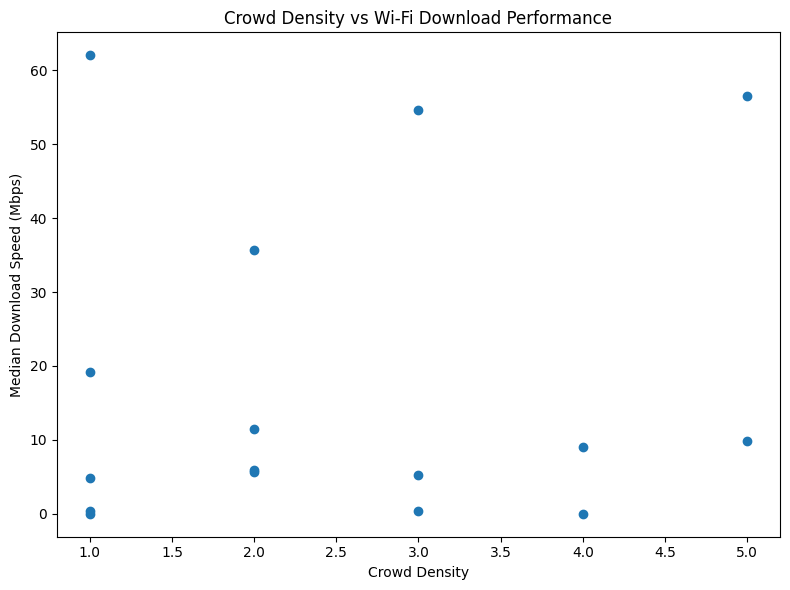

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    problem_data["crowd_density"],
    problem_data["median_download"]
)

plt.xlabel("Crowd Density")
plt.ylabel("Median Download Speed (Mbps)")
plt.title("Crowd Density vs Wi-Fi Download Performance")

plt.tight_layout()
plt.show()

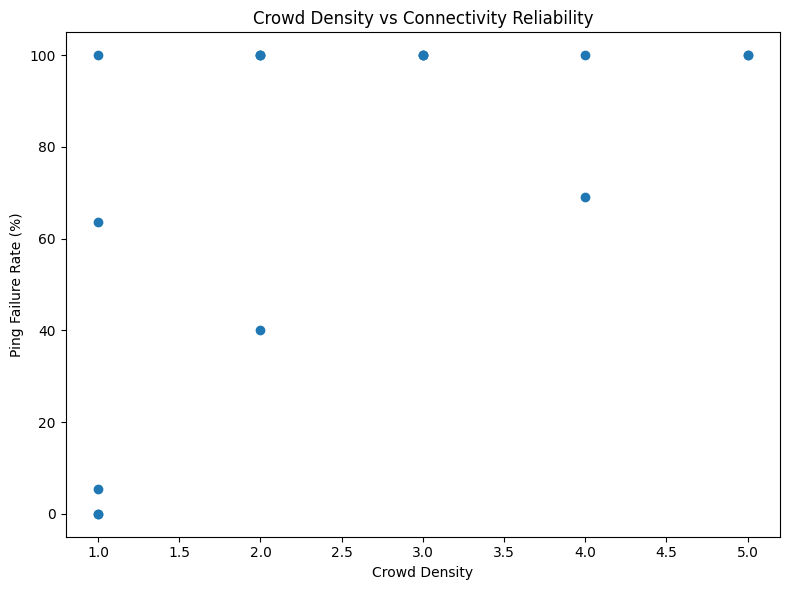

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    problem_data["crowd_density"],
    problem_data["ping_failure_rate"]
)

plt.xlabel("Crowd Density")
plt.ylabel("Ping Failure Rate (%)")
plt.title("Crowd Density vs Connectivity Reliability")

plt.tight_layout()
plt.show()

In [34]:
print(
    problem_data[
        [
            "median_signal_dbm",
            "median_download",
            "median_ping",
            "ping_failure_rate"
        ]
    ].corr()
)

                   median_signal_dbm  median_download  median_ping  \
median_signal_dbm           1.000000         0.451260    -0.189758   
median_download             0.451260         1.000000    -0.528495   
median_ping                -0.189758        -0.528495     1.000000   
ping_failure_rate          -0.276773        -0.231479    -0.082692   

                   ping_failure_rate  
median_signal_dbm          -0.276773  
median_download            -0.231479  
median_ping                -0.082692  
ping_failure_rate           1.000000  
